# 🌌 Linear regression!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside **problem.ipynb** and **linear_models.py**.
- Answer the follow-up questions in markdown format within this notebook. A few sentences is enough, no requirements for length of answers.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Submit **problem.ipynb** and **linear_models.py** to Canvas. Deliever the notebook such that outputs are saved, ideally *restart* the kernel followed by *run all*.

Good luck!

---

## 🔋 Problem 1: Predicting power consumption

### ❗️ The problem

You must develop a predictive model to estimate **power consumption** based on **network activity**.
️
Use `LinearRegression` class from `linear_models.py` stored in this folder. Your task is to complete two functions: `fit` (find the optimal parameters of the regression) and `predict` (apply them to the test data).

### 📋 Formal requirements
1. **Implementation**: 
   - Use standard Python libraries (numpy, math, pandas, etc.)
   - Implement `LinearRegression` class from `linear_models.py` from scratch
   - Optimize weights and bias with gradient descent from scratch

2. **Discussion**:
   - Visualize the training loss curve. Is it stable?
   - Visualize the fitted curve and derive the resulting Energy consumption formula.
   - Analyze the prediction error distribution. What is an unbiased estimator?
   - What does it tell you when the gradient in SGD is close to zero?

In [113]:
# The `%autoreload` IPython magic command allows instant updates from `linear_models.py`.
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from linear_models import LinearRegression, LogisticRegression  # <--- You will implement this

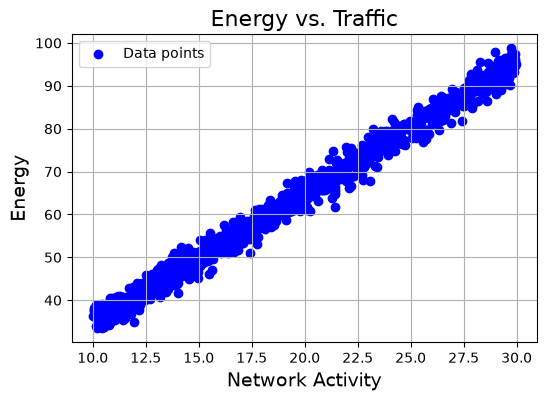

In [115]:
# Load data
data = pd.read_csv('regression.csv')

# Plot the data
plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
plt.legend()
plt.show()

TRAINING:
- X shape: (1000, 1)
- y shape: (1000,)
Training started for 1000 iterations...
Training completed. Final cost: 5.222936820152355


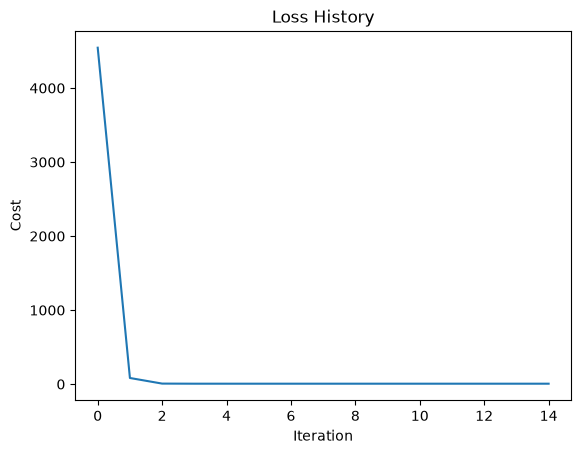


PREDICTING:
xTest shape: (11, 1)
Predictions: [8.13834022e-01 3.20508157e+02 6.40202480e+02 9.59896802e+02
 1.27959113e+03 1.59928545e+03 1.91897977e+03 2.23867409e+03
 2.55836842e+03 2.87806274e+03 3.19775706e+03]

DERIVED FORMULA:
y = 3.1969432275799208*x + 0.8138340222229041


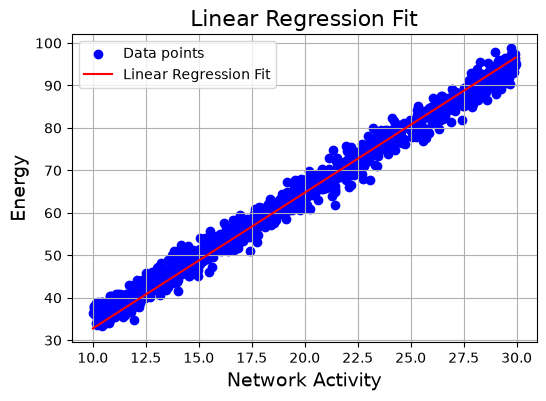


ERROR ANALYSIS:
Mean residual error: 0.30792370159065147


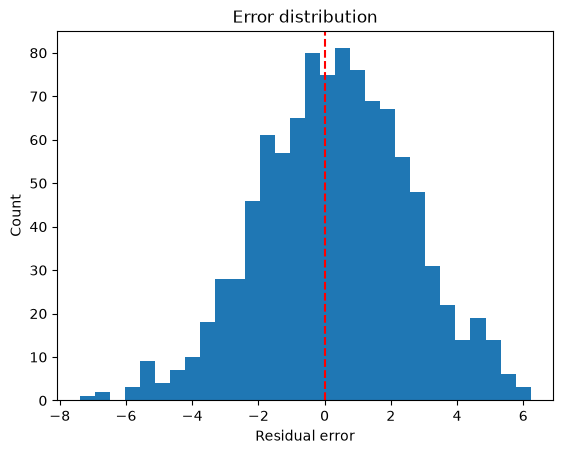

In [116]:
# Model
linearRegressionModel = LinearRegression(scale_features=False)

# * Training
print("TRAINING:")
# Reshape to 2D array
X = data['Net_Activity'].values.reshape(-1, 1)                                          # ? Reshape to 2D array as required by the fit() function                  
y = data['Energy'].values

print("- X shape:", X.shape)
print("- y shape:", y.shape)

# Fit the linear regression model
linearRegressionModel.fit(X, y)

# Plot the loss history to visualize convergence
plt.plot(linearRegressionModel.loss_history[:15])
plt.title("Loss History")
plt.xlabel("Iteration")
plt.ylabel("Cost")

plt.show()


# * Predicting
print("\nPREDICTING:")
# Reshape to 2D array for prediction
xTest = np.array([0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]).reshape(-1, 1)

print("xTest shape:", xTest.shape)

# Predict using the trained model
prediction = linearRegressionModel.predict(xTest)

print("Predictions:", prediction)


# * Formula
print("\nDERIVED FORMULA:")
print("y = ", end="")

# Unscale the coefficients and constant to get the original formula
coefficients = linearRegressionModel.unscaledWeights
constant = linearRegressionModel.unscaledBias
yHat = lambda x: sum(coef * x for coef in coefficients) + constant

for coef in coefficients:
    print(f"{coef}*x + ", end="")
    
print(f"{constant}")

# Plot the predictions along with the original data
xPlot: np.ndarray = np.linspace(
    data["Net_Activity"].min(),
    data["Net_Activity"].max(),
    100
).reshape(-1, 1)
yPlot = yHat(xPlot)

plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.plot(xPlot, yPlot, c='red', label='Linear Regression Fit')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Linear Regression Fit', fontsize=16)
plt.legend()
plt.show()


# * Error
print("\nERROR ANALYSIS:")
yPred = linearRegressionModel.predict(X)
errors = y - yPred
print("Mean residual error:", np.mean(errors))

plt.hist(errors, bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual error")
plt.ylabel("Count")
plt.title("Error distribution")
plt.show()



***NOTE: The current answers are given based on the prerequisite that `scaled_features` is set to `False`!**. If you want to enable `scaled_features` you need to alter the `lr` and `n_iterations` accordingly!*

### ❓ Is the training loss curve stable?

Yes, the loss curve is stable as it: generally decreases as the iterations increase, eventually flattens out, does not grow without a bound, nor does it show large, continuous jumps or oscillations

### ❓ Derive the resulting energy consumption formula

Using 1000 iterations of training the linear regression model, i found that the formula for energy consumption is given as:
$$
y = 3.1969432275799208*x + 0.8138340222229041
\newline
\Rightarrow y \approx 3.2*x + 0.8
$$

### ❓ Analyze prediction error distribution. What is an unbiased estimator?

The residuals are defined as $r=y-\hat{y}$. Their distribution is approximately centered around zero, and the mean residual is close to zero. This indicates that the model does not systematically overpredict nor underpredict on this dataset. The spread of the residuals represents the remaining prediction error. However, a mean residual of zero on one dataset does not mean that the estimator is unbiased in general. An estimator $\hat{\theta}$ is unbiased if its expected value equals the true parameter over repeated samples:
$$
E[\hat{\theta}] = \theta
$$

A narrow residual distribution indicates more accurate predictions, while being centered around zero indicates little systematic bias.

### ❓ What does it tell you when the gradient in SGD is close to zero?
When the gradient in SGD is close to zero, it means the model parameters are near a point where changing them slightly will not reduce the loss much. In other words: the weights and bias are close to an optimum, the loss curve is flattening, the model is making progress slowly, and the current predictions are reasonably suited to the training data

## 🔋 Problem 2: Logistic regression

### Your task
1. Implement logistic regression
2. Train your model on binary classification data
3. Engineer features to improve the model's performance

### Formal requirements
1. **Implementation**:
   - Same as before, use standard libraries
   - Implement gradient descent

2. **Performance**: Achieve at least **0.88** classification accuracy on the test set

3. **Discussion**:
   - Explain poor initial performance and your improvements
   - What is the model's inductive bias. Why is it important?
   - Plot the ROC curve, what does the area under the curve measure?

In [117]:
data = pd.read_csv('classification.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

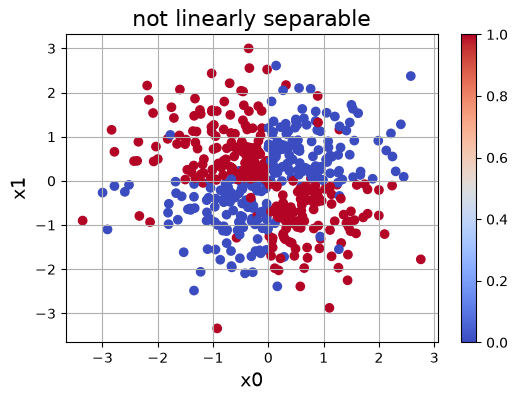

In [118]:
# visualize x0 and x1 of train on scatterplot with colors corresponding to y
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('not linearly separable', fontsize=16)
plt.colorbar()
plt.show()

TRAINING:
- X shape: (500, 3)
- y shape: (500,)
Training started for 1000 iterations...
Training completed. Final cost: 0.4486703196587533


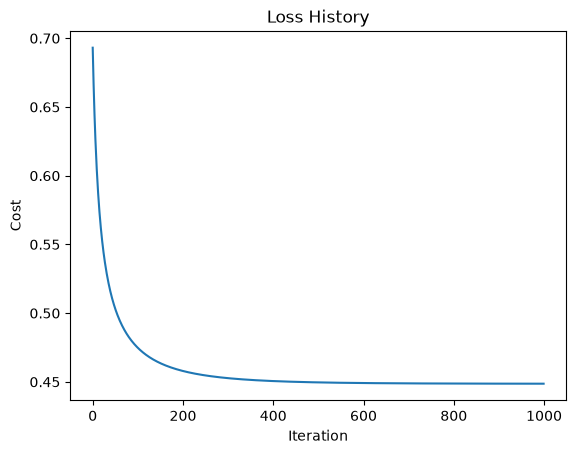


PREDICTING:

ERROR ANALYSIS:
Number of incorrect predictions: 49
Test accuracy: 0.902


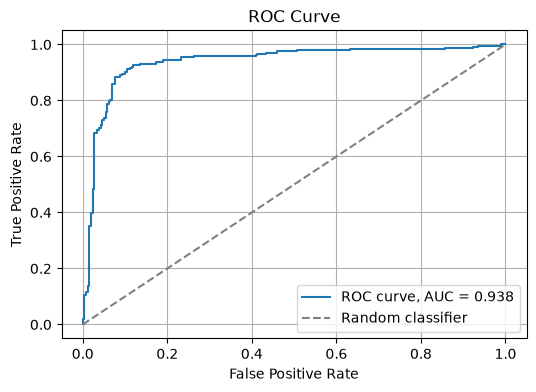

AUC: 0.9377913776254025


In [119]:
# Model
logisticRegressionModel = LogisticRegression(lr = 0.2, n_iterations=1000, scale_features=True)

# * Feature Engineering
def engineerFeatures(X):
    x0 = X[:, 0]
    x1 = X[:, 1]

    return np.column_stack([
        x0,
        x1,
        x0 * x1
    ])

# * Training
print("TRAINING:")
# Reshape to 2D array
X = engineerFeatures(train[['x0', 'x1']].values)
y = train['y'].values

print("- X shape:", X.shape)
print("- y shape:", y.shape)

# Fit the logistic regression model
logisticRegressionModel.fit(X, y)

# Plot the loss history to visualize convergence
plt.plot(logisticRegressionModel.loss_history)
plt.title("Loss History")
plt.xlabel("Iteration")
plt.ylabel("Cost")

plt.show()


# * Predicting
print("\nPREDICTING:")

# Predict probabilities and class labels for the test set
xTest = engineerFeatures(test[["x0", "x1"]].values)
yTest = test["y"].values

probabilities = logisticRegressionModel.predict_proba(xTest)
predictions = logisticRegressionModel.predict(xTest)

# // print("Predicted probabilities:", probabilities)
# // print("Predicted classes:", predictions)


# * Error
print("\nERROR ANALYSIS:")

# Classification error
errors = yTest - predictions
misclassified = np.sum(errors != 0)
accuracy = np.mean(predictions == yTest)

print("Number of incorrect predictions:", misclassified)
print("Test accuracy:", accuracy)

# ROC curve and AUC
thresholds = np.r_[np.inf, np.sort(np.unique(probabilities))[::-1], -np.inf]

predictedPositive = probabilities[:, None] >= thresholds[None, :]

truePositive = np.sum(
    predictedPositive & (yTest[:, None] == 1),
    axis=0
)
falsePositive = np.sum(
    predictedPositive & (yTest[:, None] == 0),
    axis=0
)

positive_count = np.sum(yTest == 1)
negative_count = np.sum(yTest == 0)

tpr = truePositive / positive_count
fpr = falsePositive / negative_count

# Numerical integration using the trapezoidal rule
auc = np.trapezoid(tpr, fpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve, AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.show()

print("AUC:", auc)

### ❓ Explain poor initial performance and your improvements

The initial model performed poorly because it used only the raw features $x_0$ and $x_1$. Logistic regression assumes a linear decision boundary:

$$
z = w_0x_0 + w_1x_1 + b
$$

However, the data is not linearly separable in 2D, so a straight line cannot classify the observations accurately. This resulted in low accuracy and an AUC close to $0.5$.

So to improve the model, I added the interaction feature $x_0x_1$:

$$
z = w_0x_0 + w_1x_1 + w_2x_0x_1 + b
$$

Adding the interaction feature $x_0x_1$ mapped the data into a higher-dimensional feature space where a linear classifier could separate it. This allows logistic regression to represent a nonlinear decision boundary when viewed in the original feature space. The interaction feature improved performance because it better captured the relationship between the two variables.

### ❓ What is the model's inductive bias? Why is it important?

The inductive bias is the assumption a model makes about the relationship between the input features and the target. Logistic regression assumes that the log-odds of the positive class are a linear combination of the input features:

$$
\log\left(\frac{P(y=1)}{1-P(y=1)}\right)
=
w_0x_0+w_1x_1+\cdots+b
$$

Therefore, the model prefers relatively simple, linear relationships. After feature engineering, the model is still linear in its parameters, but it can represent nonlinear relationships in the original variables.

Inductive bias is important because it determines which patterns the model can learn and how well it generalizes to unseen data. A bias that is too simple causes underfitting, while one that is too flexible can cause overfitting.

### ❓ What does the area under the ROC curve measure?

The area under the ROC curve, or AUC, measures how well the model separates the two classes across all possible classification thresholds.

The ROC curve plots the true positive rate against the false positive rate for different probability thresholds.

An AUC of $1.0$ represents perfect separation, while an AUC of $0.5$ represents random guessing. AUC can also be interpreted as the probability that the model assigns a higher predicted probability to a randomly selected positive example than to a randomly selected negative example.

Unlike accuracy, AUC does not depend on using only the fixed threshold of $0.5$.